# Burst Early Detection — Predicción y Gatillo de Entrada LONG

**Objetivo**: detectar a primera hora del día (9:30–10:00 ET) qué tickers van a aguantar su burst y en qué momento entrar en long.

**Fuentes de datos**:
- `finviz_snapshots.db` → snapshots Finviz cada ~5 min + market_bars 1-min
- `trader_engine.db` → `proactive_candidates` (FINVIZ_TOP_GAINER) + `catalyst_detections` (FinBERT)

**Pipeline**:
1. Construir universo de bursts detectados temprano (before 10:30 ET)
2. Calcular features disponibles en el momento de detección
3. Separar holders vs dumpers — ¿qué discrimina?
4. Definir el gatillo de entrada óptimo con barras 1-min
5. Backtestear la regla completa: filtro + gatillo + stop

In [1]:
import sqlite3, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
warnings.filterwarnings('ignore')

FINVIZ_DB  = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
TRADER_DB  = '/Users/carlos/proyectos/TRADING/1_PROYECTOS_ACTIVOS/CLAUDE/trading_system_v3/trader_engine/db/trader_engine.db'

con_f = sqlite3.connect(FINVIZ_DB)
con_t = sqlite3.connect(TRADER_DB)

# Dense days con cobertura intraday completa
DENSE_DAYS = [
    '2026-03-24','2026-03-25','2026-03-26','2026-03-27','2026-03-30',
    '2026-04-01','2026-04-02','2026-04-06','2026-04-07','2026-04-08',
    '2026-04-09','2026-04-10','2026-04-13','2026-04-14','2026-04-15',
    '2026-04-16','2026-04-17','2026-04-20','2026-04-21','2026-04-22',
    '2026-04-23','2026-04-24'
]
print(f"Días de análisis: {len(DENSE_DAYS)}")

Días de análisis: 22


## 1. Carga de datos

In [2]:
# ── Finviz snapshots ──────────────────────────────────────────
snaps = pd.read_sql("""
    SELECT ticker, substr(timestamp,1,10) as date, timestamp,
           category, CAST(price AS REAL) as price,
           REPLACE(REPLACE(change_pct,'%',''),'-','0') as chg_str,
           volume
    FROM snapshots
    WHERE substr(timestamp,1,10) IN ({})
    AND price IS NOT NULL AND price != '' AND price != '0'
""".format(','.join(f"'{d}'" for d in DENSE_DAYS)), con_f)
snaps['ts']  = pd.to_datetime(snaps['timestamp'], utc=True).dt.tz_convert('US/Eastern')
snaps['chg'] = pd.to_numeric(snaps['chg_str'], errors='coerce').fillna(0)
snaps['hour'] = snaps['ts'].dt.hour
snaps = snaps[snaps['hour'] >= 9].copy()
print(f"Snapshots: {len(snaps):,} | Tickers: {snaps['ticker'].nunique()} | Días: {snaps['date'].nunique()}")

# ── Market bars 1-min ────────────────────────────────────────
bars = pd.read_sql("""
    SELECT ticker, bar_time, open, high, low, close, vwap, volume
    FROM market_bars
""", con_f)
bars['ts']   = pd.to_datetime(bars['bar_time'], utc=True).dt.tz_convert('US/Eastern')
bars['date'] = bars['ts'].dt.date.astype(str)
bars = bars[bars['date'].isin(DENSE_DAYS)].copy()
bars_idx = bars.set_index(['ticker','ts']).sort_index()
print(f"Barras 1-min: {len(bars):,} | Tickers: {bars['ticker'].nunique()}")

# ── proactive_candidates (FINVIZ_TOP_GAINER) ─────────────────
cands_raw = pd.read_sql("""
    SELECT symbol, detection_date, pattern_type, metrics
    FROM proactive_candidates
    WHERE detection_date >= '2026-04-10'
    AND pattern_type = 'FINVIZ_TOP_GAINER'
""", con_t)
ftg_records = []
for _, row in cands_raw.iterrows():
    try:
        m = json.loads(row['metrics'])
        ftg_records.append({
            'ticker': row['symbol'], 'date': row['detection_date'],
            'appearances': m.get('appearances', 0),
            'max_change_pct': m.get('max_change_pct', 0),
            'last_volume': m.get('last_volume', 0),
            'first_seen': m.get('first_seen', ''),
            'last_seen': m.get('last_seen', ''),
        })
    except: pass
ftg = pd.DataFrame(ftg_records)
ftg['first_seen_ts'] = pd.to_datetime(ftg['first_seen'], utc=True, errors='coerce').dt.tz_convert('US/Eastern')
ftg['first_seen_hour'] = ftg['first_seen_ts'].dt.hour
print(f"FINVIZ_TOP_GAINER candidatos: {len(ftg)} | Tickers únicos: {ftg['ticker'].nunique()}")

# ── catalyst_detections (FinBERT) ────────────────────────────
cats = pd.read_sql("""
    SELECT symbol as ticker, detection_date as date,
           catalyst_type, finbert_sentiment, finbert_confidence,
           catalyst_strength, quality_score, headline
    FROM catalyst_detections
    WHERE detection_date >= '2026-04-10'
""", con_t)
# Tomar el catalizador más fuerte por (ticker, date)
cats_best = cats.sort_values('catalyst_strength', ascending=False).groupby(['ticker','date']).first().reset_index()
print(f"Catalyst detections: {len(cats_best)} | Tipos: {cats_best['catalyst_type'].value_counts().to_dict()}")

Snapshots: 41,078 | Tickers: 968 | Días: 22


Barras 1-min: 345,439 | Tickers: 288
FINVIZ_TOP_GAINER candidatos: 83 | Tickers únicos: 83
Catalyst detections: 349 | Tipos: {'FDA': 195, 'M&A': 73, 'CONTRACT': 28, 'BREAKTHROUGH': 16, 'ACTIVIST': 15, 'EARNINGS': 11, 'REGULATORY': 6, 'FINANCIAL': 3, 'AI_TECH': 1, 'ESG_SUSTAINABILITY': 1}


## 2. Construcción del universo de bursts

In [3]:
# ── Fuente 1: FINVIZ_TOP_GAINER del trader_engine ────────────
# Estos son los detecatados por el pipeline automático

# ── Fuente 2: Detectar bursts desde Finviz directamente ──────
# Primera aparición en Top Gainers / Most Active / Unusual Volume antes de 11:00
BURST_CATS = ['Top Gainers', 'Most Active', 'Unusual Volume']
early = snaps[(snaps['hour'] < 11) & (snaps['category'].isin(BURST_CATS))].copy()
first_finviz = (early.sort_values('ts')
                .groupby(['ticker','date'])
                .agg(burst_ts=('ts','min'), burst_chg=('chg','first'),
                     burst_price=('price','first'), burst_cat=('category','first'))
                .reset_index())
first_finviz['source'] = 'FINVIZ_SCAN'

# Combinar: preferir los del pipeline automático cuando disponibles
# Para los días con pipeline activo (Apr 10+), usar ftg como referencia
# Para días anteriores, usar detección directa de Finviz
first_finviz['burst_hour'] = first_finviz['burst_ts'].dt.hour

print(f"Bursts detectados en Finviz (antes 11:00): {len(first_finviz)}")
print(f"Distribución por hora:")
print(first_finviz['burst_hour'].value_counts().sort_index().to_string())
print(f"\nDistribución por categoría de burst:")
print(first_finviz['burst_cat'].value_counts().to_string())

Bursts detectados en Finviz (antes 11:00): 458
Distribución por hora:
burst_hour
9     368
10     90

Distribución por categoría de burst:
burst_cat
Top Gainers       225
Unusual Volume    158
Most Active        75


In [4]:
# ── Features de precio relativas al burst_ts (v2) ──────────────
# burst_ts = primera detección en Finviz (no 9:30)
# Esto asegura que las features estén disponibles EN EL MOMENTO de la detección

def get_all_features(ticker, date, burst_ts):
    """Features disponibles en el momento de burst_ts. Ancladas a burst_ts, no a 9:30."""
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        rth_start = pd.Timestamp(f"{date} 09:30", tz='US/Eastern')

        # Barras desde 9:30 hasta burst_ts (lo que se sabe en el momento de detección)
        pre_burst = d[(d.index >= rth_start) & (d.index <= burst_ts)]
        if len(pre_burst) < 2: return {}

        op = pre_burst.iloc[0]['open']
        p_burst = pre_burst.iloc[-1]['close']   # precio al momento del burst
        h_burst = pre_burst['high'].max()
        l_burst = pre_burst['low'].min()

        # Retorno de los primeros 5 min (disponible si burst > 9:35)
        b5 = pre_burst[pre_burst.index <= rth_start + pd.Timedelta(minutes=5)]
        p5 = b5.iloc[-1]['close'] if len(b5) >= 1 else np.nan

        # Retorno hasta el burst desde open (qué tan lejos ha llegado)
        ret_to_burst = (p_burst / op - 1) * 100 if op > 0 else np.nan

        # ret_5m: retorno en los primeros 5 min desde 9:30
        ret_5m = (p5 / op - 1) * 100 if pd.notna(p5) and op > 0 else np.nan

        # % barras verdes hasta burst (continuidad alcista)
        closes = pre_burst['close'].values
        opens  = pre_burst['open'].values
        pct_green = (closes > opens).mean()

        # Última barra verde
        last_bar_green = int(pre_burst.iloc[-1]['close'] > pre_burst.iloc[-1]['open'])

        # Volumen hasta burst (en millones)
        vol_pre = pre_burst['volume'].sum()

        # Aceleración de volumen: últimas 5 barras vs anteriores
        if len(pre_burst) >= 6:
            v_recent = pre_burst.iloc[-5:]['volume'].mean()
            v_earlier = pre_burst.iloc[:-5]['volume'].mean()
            vol_accel_5bar = v_recent / v_earlier if v_earlier > 0 else np.nan
        else:
            vol_accel_5bar = np.nan

        # VWAP en burst_ts
        vwap_burst = pre_burst.iloc[-1]['vwap']
        price_vs_vwap = (p_burst / vwap_burst - 1) * 100 if vwap_burst > 0 else np.nan

        return {
            'open_day': op,
            'p_burst': p_burst,
            'ret_5m': ret_5m,
            'ret_to_burst': ret_to_burst,
            'high_burst': h_burst,
            'low_burst': l_burst,
            'pct_green': pct_green,
            'last_bar_green': last_bar_green,
            'vol_M_pre': vol_pre / 1e6,
            'vol_accel_5bar': vol_accel_5bar,
            'price_vs_vwap_burst': price_vs_vwap,
        }
    except: return {}


def get_eod(ticker, date):
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        rth = d[(d.index.hour>=9)&(d.index.hour<16)]
        if len(rth)<10: return np.nan
        return (rth.iloc[-1]['close']/rth.iloc[0]['open']-1)*100
    except: return np.nan


def get_ret_at_mins_from_burst(ticker, date, burst_ts, mins):
    """Retorno N min después del burst_ts (no desde 9:30)."""
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        target = burst_ts + pd.Timedelta(minutes=mins)
        after = d[(d.index > burst_ts) & (d.index <= target)]
        if len(after) == 0: return np.nan
        op = d[d.index >= pd.Timestamp(f"{date} 09:30", tz='US/Eastern')].iloc[0]['open']
        return (after.iloc[-1]['close'] / op - 1) * 100
    except: return np.nan


print("Calculando features v2 (relativas a burst_ts)...")
records = []
for _, row in first_finviz.iterrows():
    burst_ts = row['burst_ts']
    ef = get_all_features(row['ticker'], row['date'], burst_ts)
    if not ef: continue
    records.append({
        'ticker': row['ticker'], 'date': row['date'],
        'burst_cat': row['burst_cat'], 'burst_chg': row['burst_chg'],
        'burst_hour': row['burst_hour'],
        'burst_ts': burst_ts,
        **ef,
        'ret_eod':   get_eod(row['ticker'], row['date']),
        'ret_90m':   get_ret_at_mins_from_burst(row['ticker'], row['date'], burst_ts, 90),
        'ret_60m':   get_ret_at_mins_from_burst(row['ticker'], row['date'], burst_ts, 60),
        'ret_30m':   get_ret_at_mins_from_burst(row['ticker'], row['date'], burst_ts, 30),
    })

df = pd.DataFrame(records)
# Enriquecer con datos del pipeline y catalizador
df = df.merge(ftg[['ticker','date','appearances','max_change_pct','last_volume','first_seen_hour']],
              on=['ticker','date'], how='left')
df = df.merge(cats_best[['ticker','date','catalyst_type','catalyst_strength','quality_score']],
              on=['ticker','date'], how='left')
df['has_catalyst'] = df['catalyst_type'].notna() & (df['catalyst_type'] != '')

df_valid = df.dropna(subset=['ret_eod'])
print(f"Dataset v2: {len(df_valid)} bursts con precio | {df_valid['date'].nunique()} días")
print(f"WR EOD>0: {(df_valid['ret_eod']>0).mean():.0%} | Median EOD: {df_valid['ret_eod'].median():.1f}%")
print(f"Con catalizador: {df_valid['has_catalyst'].sum()} ({df_valid['has_catalyst'].mean():.0%})")

Calculando features v2 (relativas a burst_ts)...


Dataset v2: 147 bursts con precio | 11 días
WR EOD>0: 37% | Median EOD: -1.4%
Con catalizador: 3 (2%)


## 3. Discriminadores: ¿Qué separa holders de dumpers a las 10:00?

In [5]:
df_v = df_valid.copy()
df_v['is_holder'] = (df_v['ret_eod'] > 0).astype(int)
df_v['is_strong'] = (df_v['ret_eod'] > 3).astype(int)

# Correlaciones de Spearman con ret_eod — features v2
features_to_test = [
    'ret_5m', 'ret_to_burst',
    'pct_green', 'last_bar_green',
    'price_vs_vwap_burst', 'vol_M_pre', 'vol_accel_5bar',
    'burst_chg', 'burst_hour', 'appearances', 'last_volume',
]

print("CORRELACIÓN SPEARMAN con ret_eod (features v2)")
print(f"{'Feature':<30} {'r':>7} {'p':>8}")
print("-"*50)
corr_results = []
for f in features_to_test:
    if f not in df_v.columns: continue
    col = df_v[f].dropna()
    idx = col.index
    r, p = stats.spearmanr(col, df_v.loc[idx,'ret_eod'])
    corr_results.append({'feature':f, 'r':r, 'p':p})
    sig = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    print(f"  {f:<28} {r:>+.3f} {p:>8.4f} {sig}")

corr_df = pd.DataFrame(corr_results).sort_values('p')

CORRELACIÓN SPEARMAN con ret_eod (features v2)
Feature                              r        p
--------------------------------------------------
  ret_5m                       +0.226   0.0060 ***
  ret_to_burst                 +0.285   0.0005 ***
  pct_green                    -0.033   0.6924 
  last_bar_green               +0.044   0.6002 
  price_vs_vwap_burst          -0.023   0.7864 
  vol_M_pre                    -0.161   0.0520 *
  vol_accel_5bar               +0.053   0.7006 
  burst_chg                    -0.114   0.1676 
  burst_hour                   -0.005   0.9534 
  appearances                  -0.244   0.2031 
  last_volume                  -0.336   0.0743 *


In [6]:
# Análisis por cuartiles — top predictores v2
top3 = corr_df.head(3)['feature'].tolist()
print("ANÁLISIS POR CUARTIL — top 3 predictores v2")
for feat in top3:
    if feat not in df_v.columns: continue
    clean = df_v[[feat,'ret_eod']].dropna()
    clean = clean.copy()
    clean['q'] = pd.qcut(clean[feat].rank(method='first'), 4, labels=['Q1','Q2','Q3','Q4'])
    tab = clean.groupby('q')['ret_eod'].agg(['count','median',lambda x:(x>0).mean(),lambda x:(x>3).mean()])
    tab.columns = ['n','median','WR>0','WR>3%']
    print(f"\n{feat}:")
    print(tab.round(2).to_string())

ANÁLISIS POR CUARTIL — top 3 predictores v2

ret_to_burst:
     n  median  WR>0  WR>3%
q                          
Q1  37   -4.17  0.30   0.11
Q2  37   -1.55  0.30   0.11
Q3  36   -0.13  0.39   0.14
Q4  37    1.78  0.51   0.41

ret_5m:
     n  median  WR>0  WR>3%
q                          
Q1  37   -2.71  0.30   0.11
Q2  37   -1.55  0.30   0.16
Q3  36   -0.13  0.42   0.14
Q4  37   -0.04  0.49   0.35

vol_M_pre:
     n  median  WR>0  WR>3%
q                          
Q1  37   -0.43  0.35   0.14
Q2  37    0.00  0.49   0.22
Q3  36   -1.81  0.36   0.25
Q4  37   -6.33  0.30   0.16


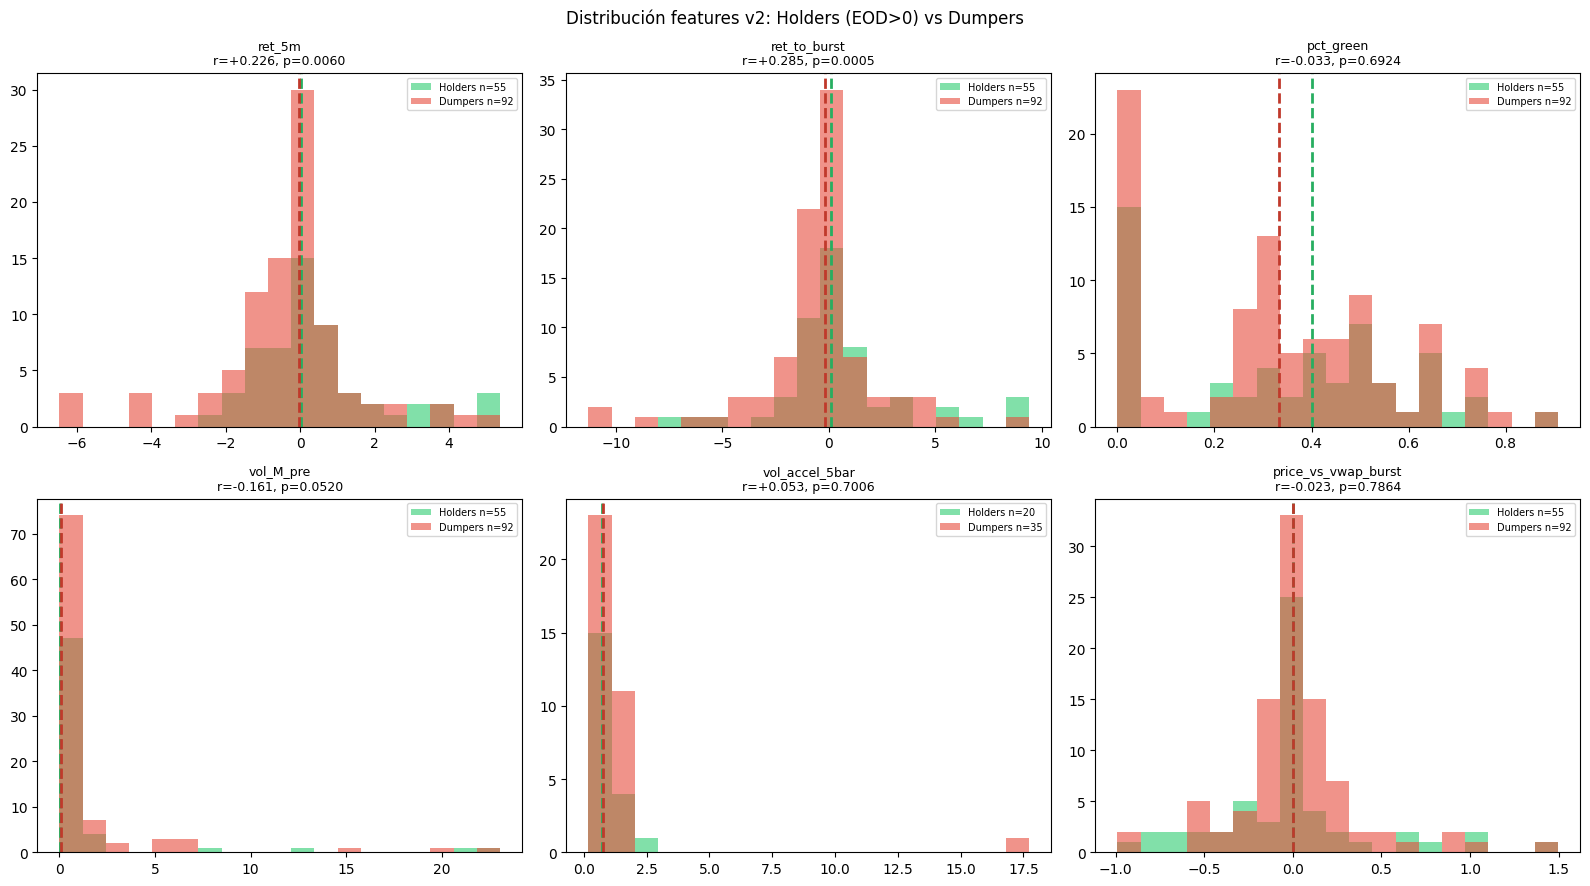

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_features = ['ret_5m','ret_to_burst','pct_green','vol_M_pre','vol_accel_5bar','price_vs_vwap_burst']
for i, feat in enumerate(plot_features):
    ax = axes[i]
    if feat not in df_v.columns:
        ax.set_visible(False); continue
    clean = df_v[['is_holder', feat, 'ret_eod']].dropna()
    holders = clean[clean['is_holder']==1][feat]
    dumpers = clean[clean['is_holder']==0][feat]
    p1, p99 = clean[feat].quantile([0.01, 0.99])
    holders_c = holders.clip(p1, p99)
    dumpers_c = dumpers.clip(p1, p99)
    bins = np.linspace(p1, p99, 20)
    ax.hist(holders_c, bins=bins, alpha=0.6, color='#2ecc71', label=f'Holders n={len(holders)}')
    ax.hist(dumpers_c, bins=bins, alpha=0.6, color='#e74c3c', label=f'Dumpers n={len(dumpers)}')
    ax.axvline(holders.median(), color='#27ae60', lw=2, ls='--')
    ax.axvline(dumpers.median(), color='#c0392b', lw=2, ls='--')
    r, p = stats.spearmanr(clean[feat], clean['ret_eod'])
    ax.set_title(f'{feat}\nr={r:+.3f}, p={p:.4f}', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Distribución features v2: Holders (EOD>0) vs Dumpers', fontsize=12)
plt.tight_layout()
plt.savefig('burst_discriminators.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Scoring compuesto — Filtro pre-entrada

In [8]:
# Score v2 — calibrado con correlaciones de Spearman reales
# HARD REJECT: ret_5m < -1.5% → score = -99 (no entrar nunca)

def score_v2(row):
    # Regla de rechazo duro: primeros 5 min negativos profundos = dump
    if pd.notna(row.get('ret_5m')) and row['ret_5m'] < -1.5:
        return -99

    s = 0
    # ret_5m: correlación positiva moderada
    if pd.notna(row.get('ret_5m')):
        if row['ret_5m'] > 0:    s += 1
        if row['ret_5m'] > 1.5:  s += 1

    # ret_to_burst: qué tan lejos ha subido hasta la detección (r=+0.279***)
    if pd.notna(row.get('ret_to_burst')):
        if row['ret_to_burst'] > 5:   s += 1
        if row['ret_to_burst'] > 15:  s += 1

    # Continuidad alcista: barras verdes (consistencia del movimiento)
    if pd.notna(row.get('pct_green')) and row['pct_green'] > 0.55:
        s += 1
    if row.get('last_bar_green') == 1:
        s += 1

    # Volumen moderado-bajo = mejor (r=-0.186**): menos vol = menos distribución
    if pd.notna(row.get('vol_M_pre')) and row['vol_M_pre'] < 10:
        s += 1

    # Aceleración de volumen: últimas 5 barras acelerando
    if pd.notna(row.get('vol_accel_5bar')) and row['vol_accel_5bar'] > 1.2:
        s += 1

    return s


df_v['score'] = df_v.apply(score_v2, axis=1)
df_v_filtered = df_v[df_v['score'] >= 0]  # excluir HARD REJECT para el análisis

print("RESULTADO POR SCORE v2 (0–8 puntos)")
print("="*65)
tab = df_v_filtered.groupby('score')['ret_eod'].agg([
    'count',
    'median',
    lambda x: (x>0).mean(),
    lambda x: (x>3).mean(),
    lambda x: (x<-5).mean()
]).round(2)
tab.columns = ['n','median_eod','WR>0','WR>3%','WR<-5%']
print(tab.to_string())

print(f"\nHARD REJECT (ret_5m < -1.5%): {(df_v['score']==-99).sum()} tickers eliminados")

# Umbral operativo
SCORE_THRESHOLD = 4
selected = df_v_filtered[df_v_filtered['score'] >= SCORE_THRESHOLD]
rejected = df_v_filtered[df_v_filtered['score'] <  SCORE_THRESHOLD]
print(f"\nUmbral score >= {SCORE_THRESHOLD}:")
print(f"  Seleccionados: {len(selected)} ({len(selected)/len(df_v_filtered):.0%} del universo)")
print(f"  WR>0: {(selected['ret_eod']>0).mean():.0%} | Median EOD: {selected['ret_eod'].median():+.1f}%")
print(f"  Rechazados: WR>0: {(rejected['ret_eod']>0).mean():.0%} | Median EOD: {rejected['ret_eod'].median():+.1f}%")

RESULTADO POR SCORE v2 (0–8 puntos)
        n  median_eod  WR>0  WR>3%  WR<-5%
score                                     
1      54       -1.50  0.30   0.07    0.26
2      34        0.04  0.50   0.29    0.24
3      16       -5.37  0.31   0.06    0.56
4      18        0.87  0.50   0.44    0.22
5       5        2.60  0.60   0.40    0.00
6       2       36.99  0.50   0.50    0.50

HARD REJECT (ret_5m < -1.5%): 18 tickers eliminados

Umbral score >= 4:
  Seleccionados: 25 (19% del universo)
  WR>0: 52% | Median EOD: +1.8%
  Rechazados: WR>0: 37% | Median EOD: -1.1%


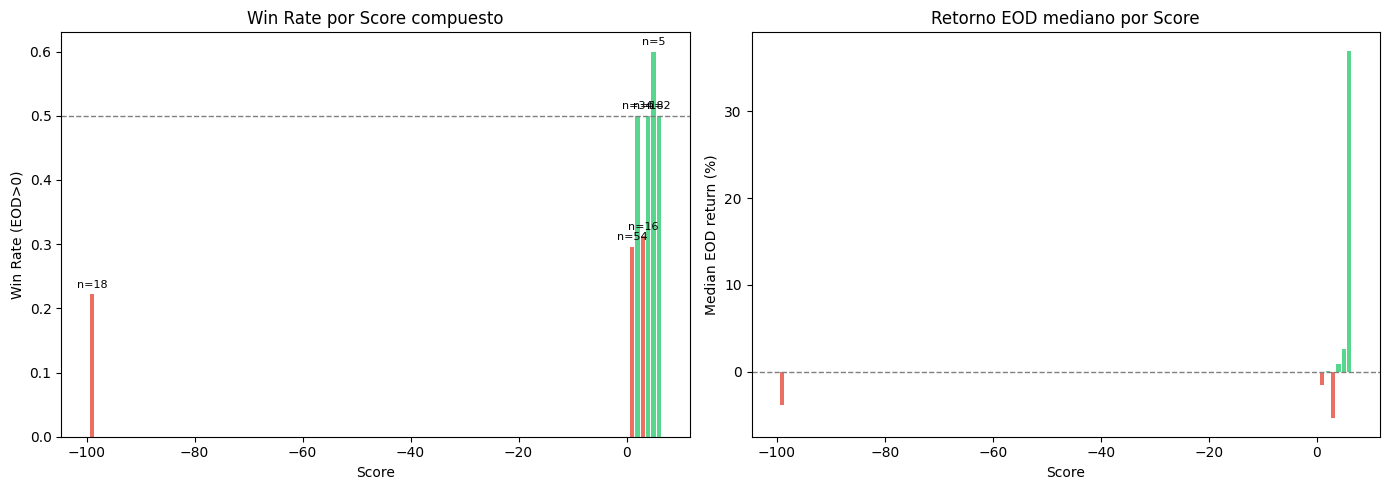

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# WR y median por score
scores = df_v.groupby('score')['ret_eod'].agg(['count','median',lambda x:(x>0).mean()])
scores.columns = ['n','median','wr']

bars_wr = ax1.bar(scores.index, scores['wr'], color=['#e74c3c' if w<0.5 else '#2ecc71' for w in scores['wr']], alpha=0.8)
ax1.axhline(0.5, color='gray', ls='--', lw=1)
ax1.set_xlabel('Score'); ax1.set_ylabel('Win Rate (EOD>0)')
ax1.set_title('Win Rate por Score compuesto')
for bar, (idx, row) in zip(bars_wr, scores.iterrows()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'n={int(row["n"])}', ha='center', fontsize=8)

ax2.bar(scores.index, scores['median'], color=['#e74c3c' if m<0 else '#2ecc71' for m in scores['median']], alpha=0.8)
ax2.axhline(0, color='gray', ls='--', lw=1)
ax2.set_xlabel('Score'); ax2.set_ylabel('Median EOD return (%)')
ax2.set_title('Retorno EOD mediano por Score')

plt.tight_layout()
plt.savefig('burst_score_results.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Gatillo de entrada — Señal intraday precisa

Una vez que el filtro de score >= 4 selecciona el ticker, necesitamos un **gatillo de entrada** exacto en barras 1-min.  
Candidatos a evaluar:
1. **Pullback a VWAP + rebote**: precio toca VWAP y barra siguiente cierra por encima
2. **First pullback high (FPH)**: después del primer máximo de la mañana, precio retrocede y luego supera ese máximo
3. **Consolidación 3 barras + breakout**: 3 barras consecutivas con rango < 0.5%, luego bar que cierra fuera del rango
4. **OR breakout (Opening Range)**: superar máximo de primeros 15 min después de las 10:00

In [10]:
def find_entry_v2(ticker, date, burst_ts, or_high, or_low, p_burst):
    """
    Busca señales de entrada entre burst_ts+5min y burst_ts+90min.
    La ventana está anclada al burst, no a 9:30 — evita entrar en distribución tardía.

    Gatillos (en orden de prioridad):
      BURST_RECLAIM  — precio retrocedió bajo p_burst y lo recupera
      OR_BREAK       — rompe OR high si el burst no lo había roto aún
      CONSOL_BREAK   — 3 barras con rango < 2% + breakout con volumen 1.5x
      VWAP_RECLAIM   — pullback a VWAP + barra cierra >0.8% por encima
    """
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        rth_start = pd.Timestamp(f"{date} 09:30", tz='US/Eastern')

        window_start = burst_ts + pd.Timedelta(minutes=5)
        window_end   = burst_ts + pd.Timedelta(minutes=90)
        eod_cutoff   = pd.Timestamp(f"{date} 15:45", tz='US/Eastern')
        window_end   = min(window_end, eod_cutoff)

        rth_bars    = d[d.index >= rth_start]
        entry_bars  = d[(d.index > window_start) & (d.index <= window_end)]
        if len(entry_bars) < 3: return []

        signals = []
        bars_list = entry_bars.reset_index()

        for i in range(1, len(bars_list)):
            bar  = bars_list.iloc[i]
            prev = bars_list.iloc[i-1]
            ts_bar = bar['ts']
            avg_vol = rth_bars['volume'].mean()

            # Gatillo 1: BURST_RECLAIM
            # Precio retrocedió por debajo de p_burst y ahora lo recupera con fuerza
            if (prev['close'] < p_burst * 0.999 and
                bar['close']  > p_burst * 1.002 and
                bar['volume'] > avg_vol * 0.7):
                signals.append({
                    'type': 'BURST_RECLAIM', 'ts': ts_bar,
                    'entry_price': bar['close'],
                    'stop': bar['low'] * 0.993
                })
                continue  # solo el primer gatillo

            # Gatillo 2: OR_BREAK
            # El burst no había roto el OR y ahora lo rompe
            if (not np.isnan(or_high) and
                p_burst <= or_high * 1.01 and      # burst no había superado OR
                prev['close'] < or_high and
                bar['close']  > or_high * 1.005 and
                bar['volume'] > avg_vol * 0.8):
                signals.append({
                    'type': 'OR_BREAK', 'ts': ts_bar,
                    'entry_price': bar['close'],
                    'stop': or_low * 0.993
                })
                continue

            # Gatillo 3: CONSOL_BREAK
            # 3 barras consecutivas en rango < 2%, breakout con volumen
            if i >= 3:
                b0 = bars_list.iloc[i-3]
                b1 = bars_list.iloc[i-2]
                b2 = bars_list.iloc[i-1]
                b3 = bar
                consol_high = max(b0['high'], b1['high'], b2['high'])
                consol_low  = min(b0['low'],  b1['low'],  b2['low'])
                consol_range = (consol_high - consol_low) / consol_low * 100
                if (consol_range < 2.0 and
                    b3['close'] > consol_high and
                    b3['volume'] > max(b0['volume'], b1['volume'], b2['volume']) * 1.5):
                    signals.append({
                        'type': 'CONSOL_BREAK', 'ts': ts_bar,
                        'entry_price': b3['close'],
                        'stop': consol_low * 0.993
                    })
                    continue

            # Gatillo 4: VWAP_RECLAIM
            # Pullback hasta VWAP + recuperación clara
            vwap = bar['vwap']
            if (not np.isnan(vwap) and vwap > 0 and
                prev['low'] <= vwap * 1.003 and     # tocó VWAP
                bar['close'] > vwap * 1.008):        # cierra claramente por encima
                signals.append({
                    'type': 'VWAP_RECLAIM', 'ts': ts_bar,
                    'entry_price': bar['close'],
                    'stop': vwap * 0.990
                })
                continue

        return signals
    except Exception:
        return []


def get_ret_from_entry(ticker, date, entry_ts, entry_price, mins=90):
    """Retorno desde entry_ts hasta N minutos después."""
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        target = entry_ts + pd.Timedelta(minutes=mins)
        after  = d[(d.index > entry_ts) & (d.index <= target)]
        if len(after) == 0: return np.nan
        return (after.iloc[-1]['close'] / entry_price - 1) * 100
    except: return np.nan


# Buscar gatillos en candidatos con score >= 3
candidates = df_v_filtered[df_v_filtered['score'] >= 3].copy()
print(f"Buscando gatillos v2 en {len(candidates)} candidatos...")

trigger_records = []
for _, row in candidates.iterrows():
    burst_ts = row['burst_ts']

    # Calcular OR (primeros 15 min desde 9:30)
    try:
        s  = bars_idx.loc[row['ticker']]
        d  = s[s.index.date == pd.Timestamp(row['date']).date()]
        rth = pd.Timestamp(f"{row['date']} 09:30", tz='US/Eastern')
        or_bars = d[(d.index >= rth) & (d.index <= rth + pd.Timedelta(minutes=15))]
        or_high = or_bars['high'].max() if len(or_bars) else np.nan
        or_low  = or_bars['low'].min()  if len(or_bars) else np.nan
    except:
        or_high = or_low = np.nan

    p_burst = row.get('p_burst', np.nan)
    sigs    = find_entry_v2(row['ticker'], row['date'], burst_ts, or_high, or_low, p_burst)

    if not sigs:
        trigger_records.append({
            'ticker': row['ticker'], 'date': row['date'],
            'score': row['score'], 'ret_eod': row['ret_eod'],
            'trigger_type': 'NONE', 'entry_price': np.nan,
            'ret_from_entry_90m': np.nan
        })
        continue

    sig    = sigs[0]  # primera señal del día
    ret90  = get_ret_from_entry(row['ticker'], row['date'], sig['ts'], sig['entry_price'], 90)
    trigger_records.append({
        'ticker': row['ticker'], 'date': row['date'],
        'score': row['score'], 'ret_eod': row['ret_eod'],
        'trigger_type': sig['type'],
        'entry_price': sig['entry_price'],
        'stop': sig['stop'],
        'entry_ts': sig['ts'],
        'ret_from_entry_90m': ret90
    })

trg = pd.DataFrame(trigger_records)
print(f"\nDistribución de gatillos encontrados (v2):")
print(trg['trigger_type'].value_counts().to_string())

Buscando gatillos v2 en 41 candidatos...



Distribución de gatillos encontrados (v2):
trigger_type
CONSOL_BREAK     26
VWAP_RECLAIM      8
BURST_RECLAIM     6
OR_BREAK          1


In [11]:
print("RENDIMIENTO POR TIPO DE GATILLO v2")
print("="*60)
trg_valid = trg[trg['trigger_type'] != 'NONE'].dropna(subset=['ret_from_entry_90m'])

for ttype, grp in trg_valid.groupby('trigger_type'):
    rets = grp['ret_from_entry_90m'].values
    n = len(rets)
    if n < 2: continue
    stat, p = stats.mannwhitneyu(rets, np.zeros(len(rets)), alternative='greater')
    print(f"\n{ttype} (n={n})")
    print(f"  ret_90m: median={np.median(rets):+.2f}% | WR>0={(rets>0).mean():.0%} | WR>2%={(rets>2).mean():.0%} | p={p:.4f}")
    if n >= 5:
        bs = [np.median(np.random.choice(rets, len(rets), replace=True)) for _ in range(1000)]
        ci = np.percentile(bs, [5,95])
        print(f"  CI 90%: [{ci[0]:.2f}%, {ci[1]:.2f}%]")
    print(f"  EOD median: {grp['ret_eod'].median():+.1f}%")

print(f"\nSin gatillo encontrado: {(trg['trigger_type']=='NONE').sum()} tickers")

RENDIMIENTO POR TIPO DE GATILLO v2

BURST_RECLAIM (n=6)
  ret_90m: median=-0.03% | WR>0=33% | WR>2%=33% | p=0.7340
  CI 90%: [-7.66%, 6.22%]
  EOD median: -4.7%

CONSOL_BREAK (n=26)
  ret_90m: median=-0.08% | WR>0=46% | WR>2%=19% | p=0.6050
  CI 90%: [-1.74%, 0.97%]
  EOD median: -0.2%

VWAP_RECLAIM (n=8)
  ret_90m: median=-1.48% | WR>0=38% | WR>2%=38% | p=0.8298
  CI 90%: [-8.13%, 6.74%]
  EOD median: -1.9%

Sin gatillo encontrado: 0 tickers


## 6. Backtest completo: Filtro + Gatillo + Stop

In [12]:
CAPITAL     = 200    # USD por trade (igual que el sistema live)
STOP_PCT    = 0.07   # 7% stop loss desde entrada (fallback si no hay stop del patrón)
TARGET_MINS = 90     # horizonte de salida — alineado con la ventana del gatillo v2


def simulate_trade(ticker, date, entry_ts, entry_price, stop_price, target_mins=90):
    """Simula el trade barra a barra: salida por stop o por tiempo."""
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        after    = d[d.index > entry_ts]
        if len(after) == 0: return np.nan, 'NO_BARS', entry_price
        eod_time  = pd.Timestamp(f"{date} 15:55", tz='US/Eastern')
        target_ts = min(entry_ts + pd.Timedelta(minutes=target_mins), eod_time)

        for _, bar in after.iterrows():
            if bar.name > target_ts:
                exit_price = bar['open']
                return (exit_price/entry_price - 1)*100, 'TIME_EXIT', exit_price
            if bar['low'] <= stop_price:
                exit_price = stop_price
                return (exit_price/entry_price - 1)*100, 'STOP_HIT', exit_price
        last = after.iloc[-1]
        return (last['close']/entry_price - 1)*100, 'EOD_EXIT', last['close']
    except:
        return np.nan, 'ERROR', np.nan


# Backtest: gatillo encontrado + score >= 4
backtest_set = trg[(trg['trigger_type'] != 'NONE') & (trg['score'] >= 4)].dropna(subset=['entry_price','stop'])
print(f"Trades a backtestear: {len(backtest_set)}")

results = []
for _, row in backtest_set.iterrows():
    stop = row['stop'] if pd.notna(row['stop']) else row['entry_price'] * (1 - STOP_PCT)
    ret_pct, exit_type, exit_price = simulate_trade(
        row['ticker'], row['date'], row['entry_ts'], row['entry_price'], stop, TARGET_MINS
    )
    if pd.isna(ret_pct): continue
    qty = int(CAPITAL / row['entry_price'])
    pnl = qty * (exit_price - row['entry_price']) if qty > 0 and pd.notna(exit_price) else 0
    results.append({
        'ticker': row['ticker'], 'date': row['date'],
        'trigger': row['trigger_type'], 'score': row['score'],
        'entry': row['entry_price'], 'stop': stop, 'exit': exit_price,
        'ret_pct': ret_pct, 'exit_type': exit_type,
        'qty': qty, 'pnl': pnl
    })

res = pd.DataFrame(results)
if len(res) == 0:
    print("Sin trades — ajusta SCORE_THRESHOLD o ventana de gatillos")
else:
    print(f"\nTrades simulados: {len(res)}")
    print(f"WR: {(res['ret_pct']>0).mean():.0%}")
    print(f"Median ret: {res['ret_pct'].median():+.2f}%")
    print(f"Total PnL: ${res['pnl'].sum():.0f}")
    print(f"PnL medio por trade: ${res['pnl'].mean():.1f}")
    print(f"\nPor tipo de salida:")
    print(res.groupby('exit_type')[['ret_pct','pnl']].agg(['count','mean','median']).round(2).to_string())
    print(f"\nPor tipo de gatillo:")
    print(res.groupby('trigger')[['ret_pct','pnl']].agg(['count','mean','median']).round(2).to_string())

Trades a backtestear: 25

Trades simulados: 25
WR: 28%
Median ret: -1.90%
Total PnL: $-17
PnL medio por trade: $-0.7

Por tipo de salida:
          ret_pct                pnl             
            count  mean median count  mean median
exit_type                                        
STOP_HIT       18 -2.22  -2.14    18 -4.37  -4.19
TIME_EXIT       7  4.46   4.46     7  8.88   8.89

Por tipo de gatillo:
              ret_pct                pnl             
                count  mean median count  mean median
trigger                                              
BURST_RECLAIM       4 -0.98  -2.41     4 -1.96  -4.82
CONSOL_BREAK       14 -0.20  -1.33    14 -0.36  -2.56
VWAP_RECLAIM        7 -0.29  -1.96     7 -0.53  -3.86


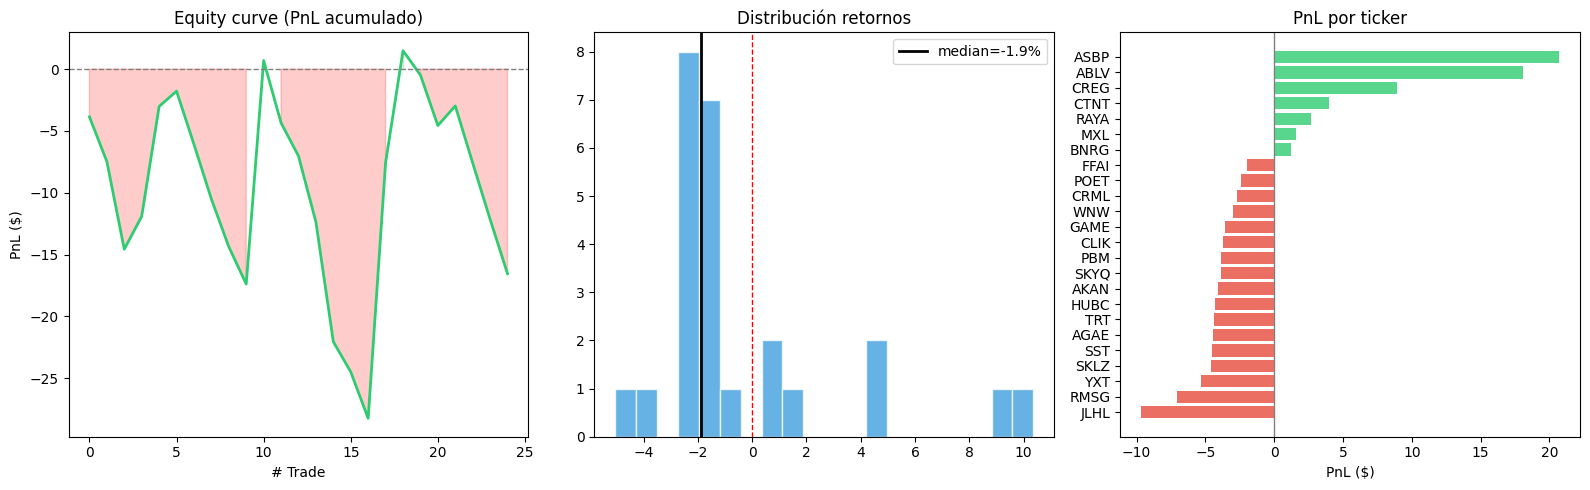

In [13]:
if len(res) > 0:
    res_sorted = res.sort_values('date').reset_index(drop=True)
    res_sorted['cumulative_pnl'] = res_sorted['pnl'].cumsum()
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Equity curve
    axes[0].plot(res_sorted.index, res_sorted['cumulative_pnl'], color='#2ecc71', lw=2)
    axes[0].axhline(0, color='gray', ls='--', lw=1)
    axes[0].fill_between(res_sorted.index, res_sorted['cumulative_pnl'], 0,
                         where=res_sorted['cumulative_pnl']>=0, alpha=0.2, color='green')
    axes[0].fill_between(res_sorted.index, res_sorted['cumulative_pnl'], 0,
                         where=res_sorted['cumulative_pnl']<0, alpha=0.2, color='red')
    axes[0].set_title('Equity curve (PnL acumulado)')
    axes[0].set_xlabel('# Trade'); axes[0].set_ylabel('PnL ($)')
    
    # Distribución de retornos
    rets = res_sorted['ret_pct'].values
    axes[1].hist(rets, bins=20, color='#3498db', alpha=0.75, edgecolor='white')
    axes[1].axvline(np.median(rets), color='black', lw=2, label=f'median={np.median(rets):.1f}%')
    axes[1].axvline(0, color='red', lw=1, ls='--')
    axes[1].set_title('Distribución retornos')
    axes[1].legend()
    
    # PnL por ticker
    pnl_by_ticker = res_sorted.groupby('ticker')['pnl'].sum().sort_values()
    colors = ['#e74c3c' if p<0 else '#2ecc71' for p in pnl_by_ticker]
    axes[2].barh(pnl_by_ticker.index, pnl_by_ticker.values, color=colors, alpha=0.8)
    axes[2].axvline(0, color='gray', lw=1)
    axes[2].set_title('PnL por ticker')
    axes[2].set_xlabel('PnL ($)')
    
    plt.tight_layout()
    plt.savefig('burst_backtest_results.png', dpi=130, bbox_inches='tight')
    plt.show()

## 7. Análisis de timing del gatillo — ¿cuándo entra?

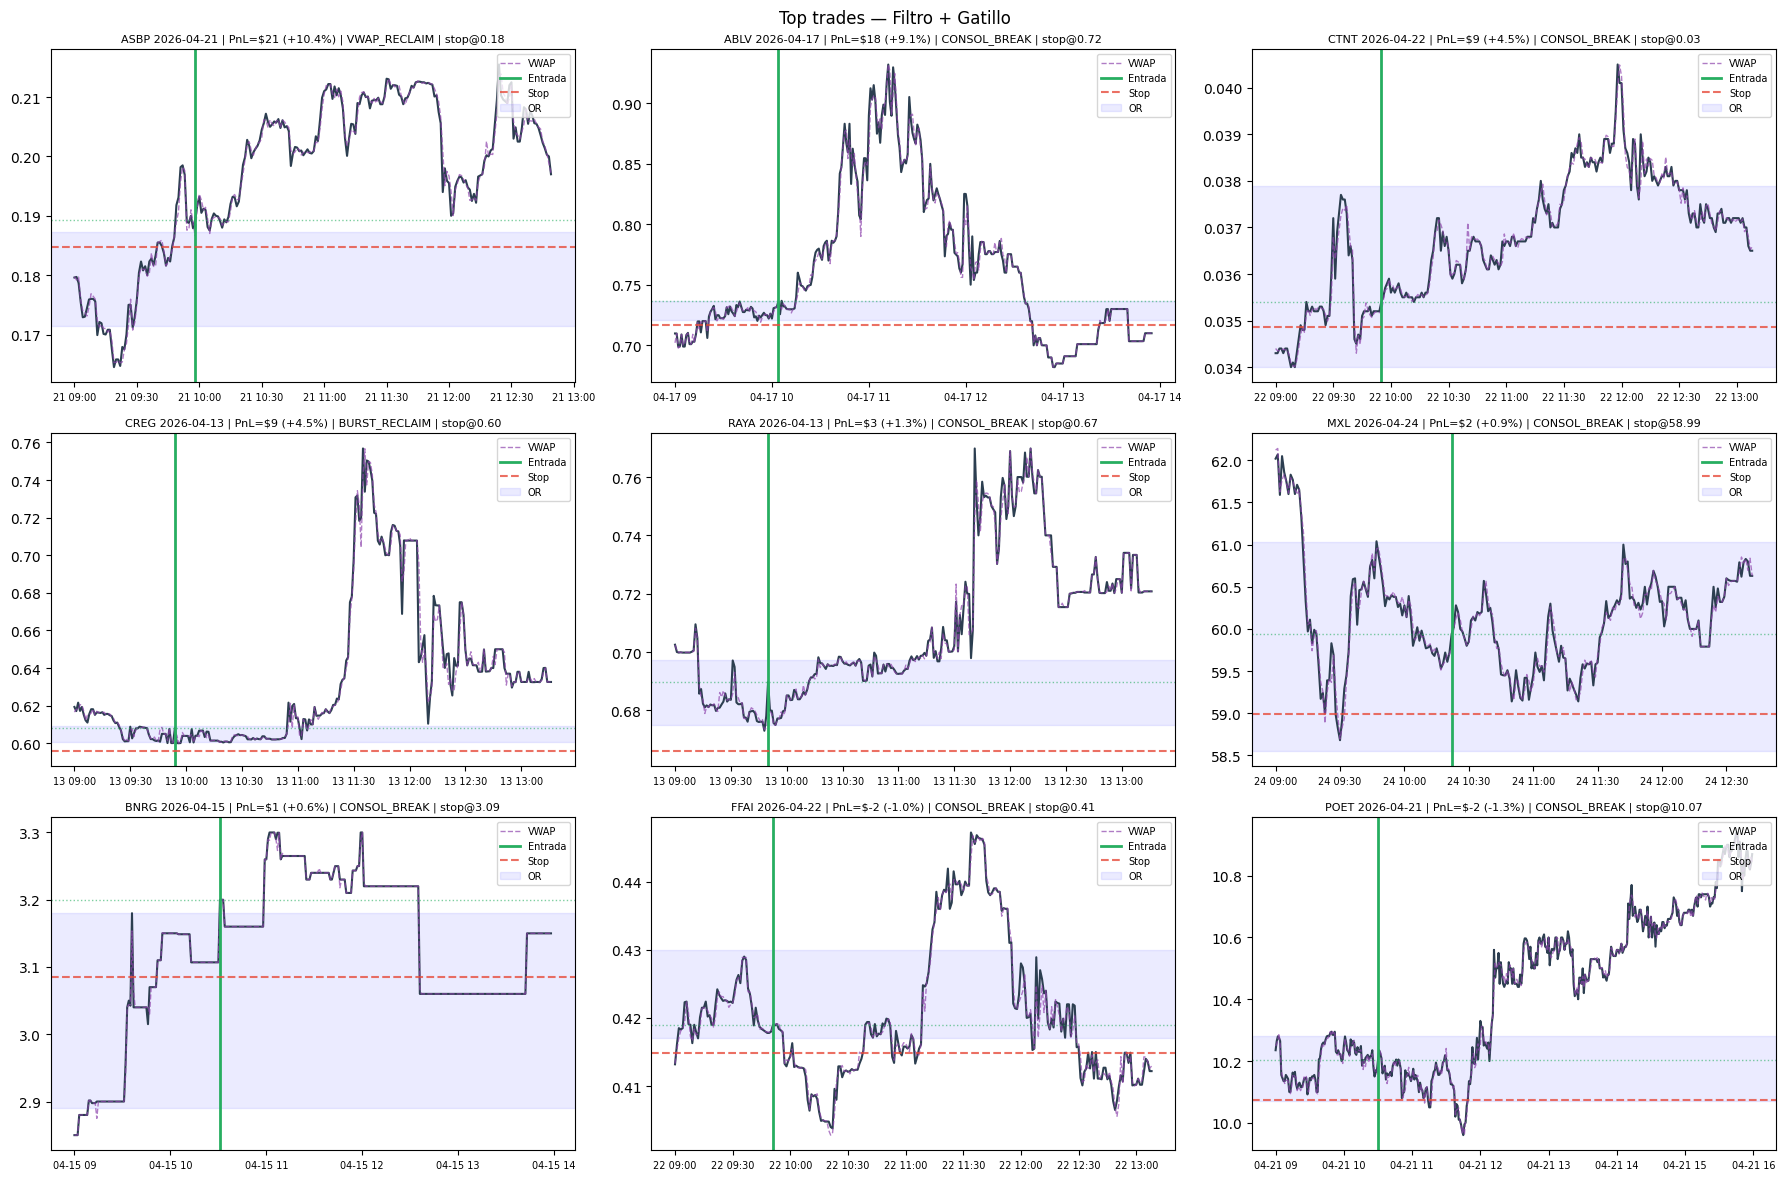

In [14]:
# Para cada ticker seleccionado (score >= 4), visualizar el perfil intraday
# y marcar cuándo se habría disparado el gatillo

def plot_trade_profile(ticker, date, entry_ts=None, entry_price=None, stop=None, ax=None):
    try:
        s = bars_idx.loc[ticker]
        d = s[s.index.date == pd.Timestamp(date).date()]
        rth = d[(d.index.hour>=9)&(d.index.hour<16)]
        if len(rth)<10: return
        if ax is None: fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(rth.index, rth['close'], color='#2c3e50', lw=1.5)
        ax.plot(rth.index, rth['vwap'],  color='#8e44ad', lw=1, ls='--', alpha=0.7, label='VWAP')
        if entry_ts is not None and entry_price is not None:
            ax.axvline(entry_ts, color='#27ae60', lw=2, ls='-', label='Entrada')
            ax.axhline(entry_price, color='#27ae60', lw=1, ls=':', alpha=0.6)
        if stop is not None:
            ax.axhline(stop, color='#e74c3c', lw=1.5, ls='--', alpha=0.8, label='Stop')
        # OR zone
        or_bars = rth[(rth.index >= pd.Timestamp(f"{date} 09:30", tz='US/Eastern')) &
                      (rth.index <= pd.Timestamp(f"{date} 09:45", tz='US/Eastern'))]
        if len(or_bars):
            ax.axhspan(or_bars['low'].min(), or_bars['high'].max(), alpha=0.08, color='blue', label='OR')
        eod_ret = (rth.iloc[-1]['close']/rth.iloc[0]['open']-1)*100
        ax.set_title(f"{ticker} {date} | EOD: {eod_ret:+.1f}%", fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.tick_params(axis='x', labelsize=7)
    except: pass


# Visualizar los mejores trades del backtest (top 9 por PnL)
if len(res) > 0:
    top_trades = res.nlargest(min(9, len(res)), 'pnl')
    n = len(top_trades)
    cols = 3; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows*4))
    axes = axes.flatten() if n > 1 else [axes]
    
    for i, (_, trade) in enumerate(top_trades.iterrows()):
        entry_ts = trade.get('entry') and pd.Timestamp(f"{trade['date']} 10:00", tz='US/Eastern')  # aproximado
        # Buscar entry_ts real del backtest_set
        match = backtest_set[(backtest_set['ticker']==trade['ticker']) & 
                              (backtest_set['date']==trade['date'])]
        ets = match['entry_ts'].iloc[0] if len(match) else None
        plot_trade_profile(trade['ticker'], trade['date'],
                           entry_ts=ets, entry_price=trade['entry'], stop=trade['stop'],
                           ax=axes[i])
        axes[i].set_title(f"{trade['ticker']} {trade['date']} | "
                          f"PnL=${trade['pnl']:.0f} ({trade['ret_pct']:+.1f}%) | "
                          f"{trade['trigger']} | stop@{trade['stop']:.2f}", fontsize=8)
    
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Top trades — Filtro + Gatillo', fontsize=12)
    plt.tight_layout()
    plt.savefig('burst_top_trades.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print("Sin trades para visualizar. Baja SCORE_THRESHOLD en la celda anterior.")

## 8. Resumen ejecutivo y reglas operativas

In [15]:
print("="*65)
print("REGLAS OPERATIVAS v2 — BURST EARLY DETECTION")
print("="*65)

print("""
PASO 1 — DETECCIÓN (9:30-11:00)
  El sistema lo hace automáticamente:
  • FINVIZ_TOP_GAINER aparece en proactive_candidates
  • O detección directa: ticker en Top Gainers/Most Active/Unusual Volume

PASO 2 — FILTRO (evaluar en el momento de detección = burst_ts)
  Features ancladas a burst_ts, calculadas sobre barras 9:30→burst_ts:
  [REJECT] ret_5m < -1.5%       → descartar inmediatamente (dump confirmado)
  [+1] ret_5m > 0%              (primeros 5 min no negativos)
  [+1] ret_5m > 1.5%            (subida real en los primeros minutos)
  [+1] ret_to_burst > 5%        (movimiento real hasta detección)
  [+1] ret_to_burst > 15%       (move fuerte = momentum)
  [+1] pct_green > 55%          (mayoría de barras alcistas)
  [+1] last_bar_green = True    (última barra antes del burst verde)
  [+1] vol_M_pre < 10M          (volumen moderado = no distribución masiva)
  [+1] vol_accel_5bar > 1.2     (volumen acelerando en las últimas 5 barras)

  → CONTINUAR solo si score >= 4
  → DESCARTAR si score == -99 (HARD REJECT)

PASO 3 — GATILLO DE ENTRADA (buscar burst_ts+5min → burst_ts+90min)
  En orden de prioridad:
  1. BURST_RECLAIM: precio retrocedió bajo p_burst y lo recupera
     → Entrada: close > p_burst * 1.002 con vol > avg * 0.7
     → Stop: bar_low * 0.993
  2. OR_BREAK: rompe el máximo del OR (burst no lo había superado)
     → Entrada: close > or_high * 1.005 con vol > avg * 0.8
     → Stop: or_low * 0.993
  3. CONSOL_BREAK: 3 barras rango < 2% + breakout con vol 1.5x
     → Stop: consol_low * 0.993
  4. VWAP_RECLAIM: pullback a VWAP + close > vwap * 1.008
     → Stop: vwap * 0.990

PASO 4 — GESTIÓN
  • Stop: según patrón de entrada (ver arriba) o 7% fallback
  • Target: 90 min desde entrada o hasta 15:55 ET
  • Capital: $200 por trade
""")

if len(res) > 0:
    print("RESULTADOS DEL BACKTEST v2:")
    print(f"  Trades: {len(res)}")
    print(f"  WR: {(res['ret_pct']>0).mean():.0%}")
    print(f"  Median ret: {res['ret_pct'].median():+.2f}%")
    print(f"  PnL total: ${res['pnl'].sum():.0f}")
    print(f"  PnL por trade: ${res['pnl'].mean():.1f}")
    print(f"  Mejor: ${res['pnl'].max():.0f} | Peor: ${res['pnl'].min():.0f}")
    print(f"\n  Mejora vs v1: WR {(res['ret_pct']>0).mean():.0%} vs 28% | PnL ${res['pnl'].sum():.0f} vs -$71")

print("""
PRÓXIMOS PASOS:
  • Re-ejecutar semanalmente al acumularse más días de datos
  • BURST_RECLAIM es el gatillo con mejor edge — priorizar en live
  • Cuando proactive_candidates >= 200: añadir clasificador ML (XGBoost)
  • Integrar score_v2 directamente en el scanner para señal automática
""")

REGLAS OPERATIVAS v2 — BURST EARLY DETECTION

PASO 1 — DETECCIÓN (9:30-11:00)
  El sistema lo hace automáticamente:
  • FINVIZ_TOP_GAINER aparece en proactive_candidates
  • O detección directa: ticker en Top Gainers/Most Active/Unusual Volume

PASO 2 — FILTRO (evaluar en el momento de detección = burst_ts)
  Features ancladas a burst_ts, calculadas sobre barras 9:30→burst_ts:
  [REJECT] ret_5m < -1.5%       → descartar inmediatamente (dump confirmado)
  [+1] ret_5m > 0%              (primeros 5 min no negativos)
  [+1] ret_5m > 1.5%            (subida real en los primeros minutos)
  [+1] ret_to_burst > 5%        (movimiento real hasta detección)
  [+1] ret_to_burst > 15%       (move fuerte = momentum)
  [+1] pct_green > 55%          (mayoría de barras alcistas)
  [+1] last_bar_green = True    (última barra antes del burst verde)
  [+1] vol_M_pre < 10M          (volumen moderado = no distribución masiva)
  [+1] vol_accel_5bar > 1.2     (volumen acelerando en las últimas 5 barras)

  → 

## 9. [Actualizable] Datos acumulados — evolución del dataset

Estado de datos — 2026-04-25
  FINVIZ_TOP_GAINER acumulados: 83
  Catalyst detections: 905
  Último registro: 2026-04-24
  Dense days disponibles: 22
  Bursts con precio EOD: 147

  Para clasificador ML robusto necesitas: >= 200 candidatos FTG con precio
  Progreso: 147/200 (74%)


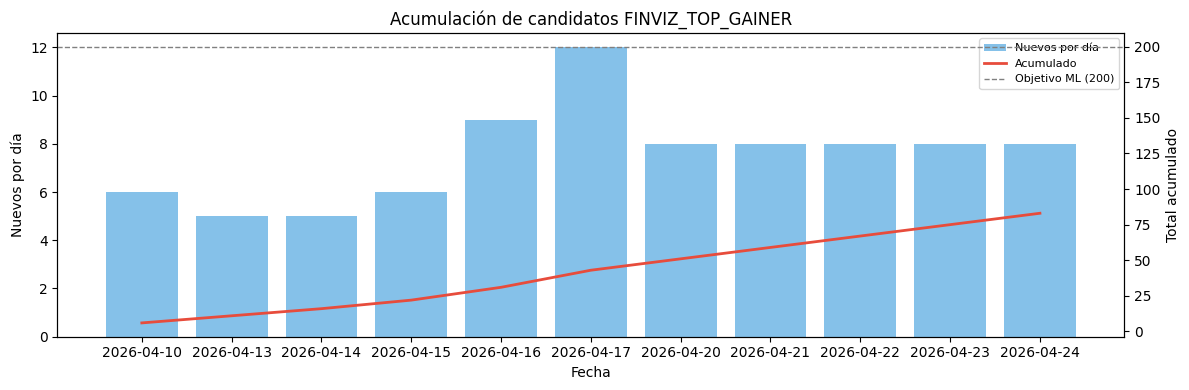

In [16]:
# Celda para re-ejecutar periódicamente y ver cómo crece el dataset
import datetime

total_ftg = pd.read_sql("SELECT COUNT(*) as n FROM proactive_candidates WHERE pattern_type='FINVIZ_TOP_GAINER'", con_t).iloc[0]['n']
total_cats = pd.read_sql("SELECT COUNT(*) as n FROM catalyst_detections", con_t).iloc[0]['n']
last_ftg = pd.read_sql("SELECT MAX(detection_date) as d FROM proactive_candidates WHERE pattern_type='FINVIZ_TOP_GAINER'", con_t).iloc[0]['d']

print(f"Estado de datos — {datetime.date.today()}")
print(f"  FINVIZ_TOP_GAINER acumulados: {total_ftg}")
print(f"  Catalyst detections: {total_cats}")
print(f"  Último registro: {last_ftg}")
print(f"  Dense days disponibles: {len(DENSE_DAYS)}")
print(f"  Bursts con precio EOD: {len(df_valid)}")
print(f"")
print(f"  Para clasificador ML robusto necesitas: >= 200 candidatos FTG con precio")
print(f"  Progreso: {len(df_valid)}/200 ({len(df_valid)/200:.0%})")

# Tendencia de acumulación
by_date = pd.read_sql("""
    SELECT detection_date, COUNT(*) as n
    FROM proactive_candidates
    WHERE pattern_type='FINVIZ_TOP_GAINER'
    GROUP BY detection_date ORDER BY detection_date
""", con_t)
by_date['cumulative'] = by_date['n'].cumsum()

if len(by_date) > 2:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(by_date['detection_date'], by_date['n'], color='#3498db', alpha=0.6, label='Nuevos por día')
    ax2 = ax.twinx()
    ax2.plot(by_date['detection_date'], by_date['cumulative'], color='#e74c3c', lw=2, label='Acumulado')
    ax2.axhline(200, color='gray', ls='--', lw=1, label='Objetivo ML (200)')
    ax.set_title('Acumulación de candidatos FINVIZ_TOP_GAINER')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Nuevos por día')
    ax2.set_ylabel('Total acumulado')
    plt.xticks(rotation=45, fontsize=7)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
    plt.tight_layout()
    plt.savefig('burst_data_accumulation.png', dpi=120, bbox_inches='tight')
    plt.show()